
# 🎓 Student Performance Prediction Assignment
Applied AI & Machine Learning (CS-333)  
Instructor: Dr. Abbas Hussain  

---

## Objective
Predict **Performance Index** using multiple ML regression models.


# Name: Syed Muhammad Subhan Waqi
# Roll Number: ME 1937
# Section: A

## Import Libraries

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns                       #visualisation
import matplotlib.pyplot as plt             #visualisation
%matplotlib inline
sns.set(color_codes=True)

## Load Dataset

In [ ]:
# Load dataset

url = "https://raw.githubusercontent.com/AbbasHussain72/PNEC-CS-333-Applied-AI-ML/main/labs/Lab-03_LR_SVC/Student_Performance.csv"
df = pd.read_csv(url)

In [ ]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [ ]:
df.dtypes

,0
Hours Studied,int64
Previous Scores,int64
Extracurricular Activities,object
Sleep Hours,int64
Sample Question Papers Practiced,int64
Performance Index,float64


In [ ]:
df.shape

(10000, 6)

## Exploratory Data Analysis

In [ ]:
# Check Type and info
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [ ]:
# Check missing values
df.isnull().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


### Check Duplicate values

In [ ]:
#

print(df.duplicated().sum())

df = df.drop_duplicates()
print(df.duplicated().sum())
print(df.shape)

127
0
(9873, 6)


### Distribution Plot

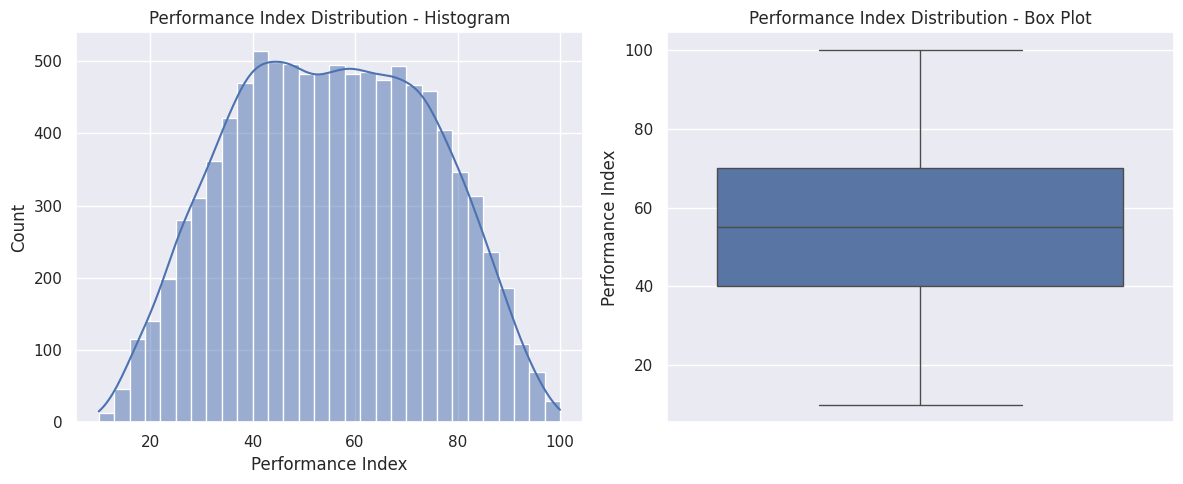

Performance Index Skewness: -0.00
Performance Index Kurotsis: -0.86


In [ ]:
# Distibution Plot

plt.figure(figsize=(12, 5)) #Setting the figure size.

# Left: Histogram
plt.subplot(1, 2, 1)
sns.histplot(df["Performance Index"], kde=True, bins=30)
plt.title("Performance Index Distribution - Histogram")
plt.xlabel("Performance Index", fontsize=12)

# Right: Box Plot
plt.subplot(1, 2, 2)
sns.boxplot(y=df["Performance Index"])
plt.title("Performance Index Distribution - Box Plot")
plt.ylabel("Performance Index", fontsize=12)

plt.tight_layout()
plt.show()

# Calculating skewness and kurtosis of the price distribution.
skewness = df["Performance Index"].skew()
kurtosis = df["Performance Index"].kurt()
print(f"Performance Index Skewness: {skewness:.2f}")
print(f"Performance Index Kurotsis: {kurtosis:.2f}")

## Encoding (if needed)

In [ ]:
# Encode categorical columns if any

df_encoded = df.copy()
df_encoded['Extracurricular Activities'] = df_encoded['Extracurricular Activities'].map({
    'Yes': 1,
    'No': 0
})

# Display dataset after encoding
df_encoded.head()


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


Encoding is applied to convert categorical variables into numerical form because machine learning algorithms cannot process textual data. In this dataset, the column Extracurricular Activities contains categorical values (Yes/No). Therefore, it is encoded into numerical values (Yes = 1, No = 0) so that the machine learning models can process the data effectively.

## Visualization

### Heatmap

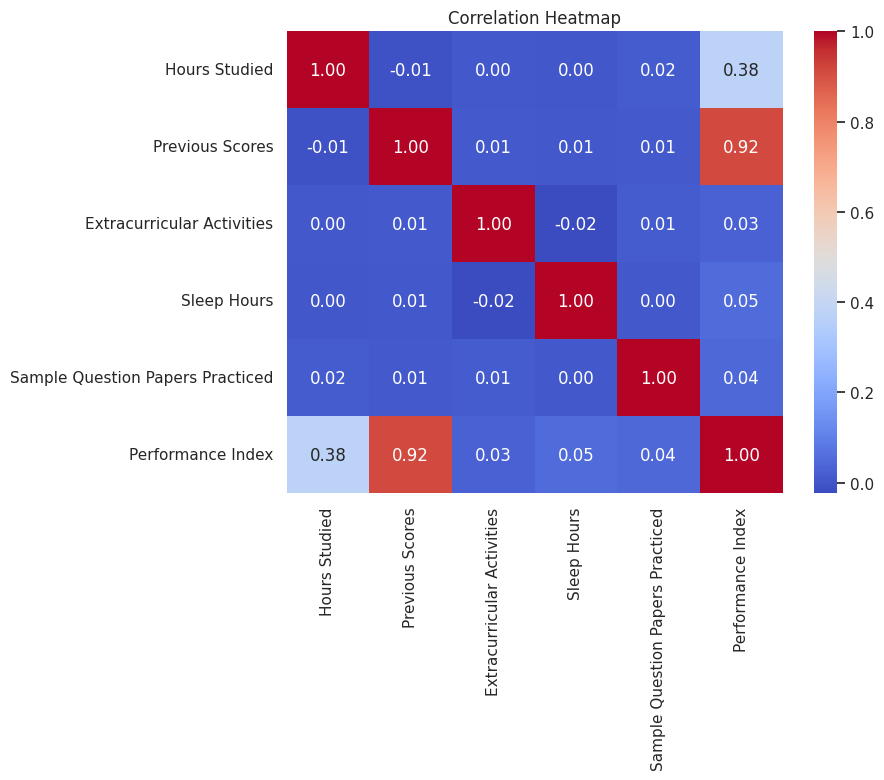

In [ ]:
plt.figure(figsize=(8,6))

corr_matrix = df_encoded.corr(numeric_only=True)

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

### Scatter Plot

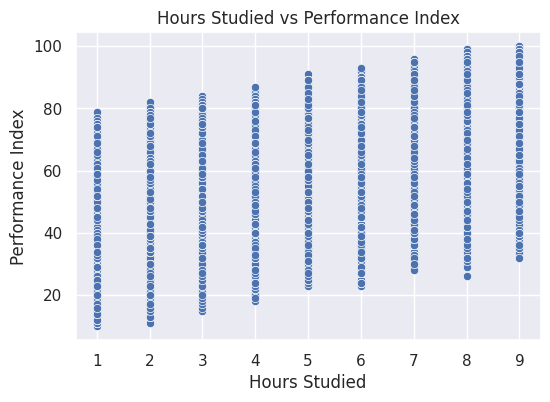

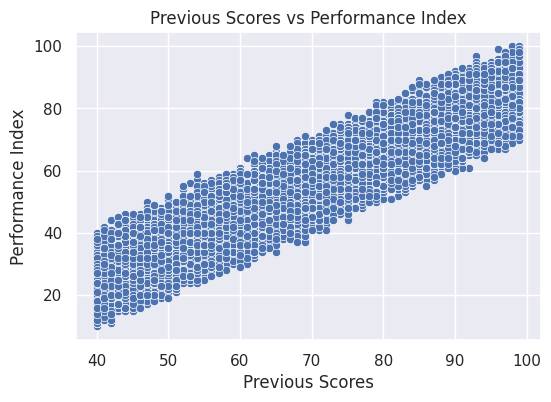

In [ ]:
# List of feature columns which have the strongest correlation among all features
features = [
    'Hours Studied',
    'Previous Scores',
]

# Scatter plots
for feature in features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df_encoded[feature], y=df_encoded['Performance Index'])
    plt.title(f'{feature} vs Performance Index')
    plt.xlabel(feature)
    plt.ylabel('Performance Index')
    plt.show()

## Correlation Analysis

In [ ]:
# Compute correlation matrix
# This was calculated in the cell of heatmap
corr_matrix

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.010676,0.004899,0.002131,0.015740,0.375332
Previous Scores,-0.010676,1.000000,0.009534,0.007975,0.008719,0.915135
Extracurricular Activities,0.004899,0.009534,1.000000,-0.024008,0.013839,0.026075
Sleep Hours,0.002131,0.007975,-0.024008,1.000000,0.004907,0.050352
Sample Question Papers Practiced,0.015740,0.008719,0.013839,0.004907,1.000000,0.043436
Performance Index,0.375332,0.915135,0.026075,0.050352,0.043436,1.000000


## Feature Selection

In [ ]:
X = df_encoded.drop("Performance Index", axis=1)
y = df_encoded["Performance Index"]

## Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split # For splitting the dataset.
from sklearn.preprocessing import MinMaxScaler # For Scaling the features.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Feature Scaling (If needed)

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit scaler on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

StandardScaler is applied to normalize feature values so that they have mean 0 and standard deviation 1. Scaling is necessary for distance-based algorithms such as SVR and KNN because these models are sensitive to differences in feature magnitudes. Tree-based models such as Random Forest and Decision Tree do not require scaling.

## Apply Regression Models (LR, SVR, Decision Tree,Random Forest, KNN)

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import time

### Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

start_train = time.time()
lr.fit(X_train, y_train)
train_time_lr = time.time() - start_train

start_test = time.time()
y_pred_lr = lr.predict(X_test)
test_time_lr = time.time() - start_test

r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

### Support Vector Regression

In [ ]:
from sklearn.svm import SVR

svr = SVR()

start_train = time.time()
svr.fit(X_train_scaled, y_train)
train_time_svr = time.time() - start_train

start_test = time.time()
y_pred_svr = svr.predict(X_test_scaled)
test_time_svr = time.time() - start_test

r2_svr = r2_score(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
mae_svr = mean_absolute_error(y_test, y_pred_svr)

### Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

start_train = time.time()
rf.fit(X_train, y_train)
train_time_rf = time.time() - start_train

start_test = time.time()
y_pred_rf = rf.predict(X_test)
test_time_rf = time.time() - start_test

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

### KNN Regressor

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)

start_train = time.time()
knn.fit(X_train_scaled, y_train)
train_time_knn = time.time() - start_train

start_test = time.time()
y_pred_knn = knn.predict(X_test_scaled)
test_time_knn = time.time() - start_test

r2_knn = r2_score(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
mae_knn = mean_absolute_error(y_test, y_pred_knn)

### Decision Tree Regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

start_train = time.time()
dt.fit(X_train, y_train)
train_time_dt = time.time() - start_train

start_test = time.time()
y_pred_dt = dt.predict(X_test)
test_time_dt = time.time() - start_test

r2_dt = r2_score(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae_dt = mean_absolute_error(y_test, y_pred_dt)

### Answer the follwing
1) Explain how Random Forest Regressor predicts a continuous value.
Include:
What is a decision tree regressor?
What is bootstrapping?
How multiple trees are used?
How final output is calculated?

**Answer**) Random Forest Regressor is an ensemble learning algorithm that predicts continuous values by combining the predictions of multiple decision trees.

A Decision Tree Regressor is a tree-based model that splits the dataset into smaller subsets based on feature values. At each node, the algorithm selects the feature and threshold that minimize the variance of the target variable. The final prediction is usually the mean value of the samples in the leaf node.

Bootstrapping is a sampling technique used in Random Forest where multiple datasets are created by randomly sampling the original dataset with replacement. Each decision tree is trained on a different bootstrap sample, which increases diversity among trees.

Random Forest builds multiple decision trees independently. Each tree makes its own prediction for the input data.

The final prediction of the Random Forest Regressor is calculated by averaging the predictions from all the tree. This averaging reduces overfitting and improves prediction accuracy.





### Answer the follwing

2) Explain how KNN Regressor predicts output for a new data point.
Include:
What is K?
How neighbors are selected?
How final predicted value is calculated?

**Answer**) K-Nearest Neighbors (KNN) Regressor is a non-parametric algorithm that predicts a continuous value based on the values of the nearest data points.

K represents the number of nearest neighbors considered for prediction. For example, if K=5, the algorithm will use the 5 closest data points to make a prediction.

To predict the output for a new data point, the algorithm calculates the distance between the new point and all training samples. Usually Euclidean distance is used.

After computing distances, the algorithm selects the K closest neighbors with the smallest distance values.

The final predicted value is calculated by taking the average of the target values of these K neighbors. Because KNN relies on distance calculations, feature scaling is important to ensure all features contribute equally to the distance computation.

## Generate a Comparison Table of Regression Models

Your output should look like this:

| Model | MAE | RMSE | R2 Score |Training Time|Testing Time|
|-------|-----|------|----------|-------------|------------|
| Linear Regression | | | |||
| SVR | | | |||
| Decision Tree | | | |||
| Random Forest | | | |||
| KNN | | | |||

---

In [ ]:
# Select best model based on R2
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "SVR",
        "Random Forest",
        "KNN",
        "Decision Tree"
    ],

    "R2 Score": [
        r2_lr,
        r2_svr,
        r2_rf,
        r2_knn,
        r2_dt
    ],

    "RMSE": [
        rmse_lr,
        rmse_svr,
        rmse_rf,
        rmse_knn,
        rmse_dt
    ],

    "MAE": [
        mae_lr,
        mae_svr,
        mae_rf,
        mae_knn,
        mae_dt
    ],

    "Training Time": [
        train_time_lr,
        train_time_svr,
        train_time_rf,
        train_time_knn,
        train_time_dt
    ],

    "Testing Time": [
        test_time_lr,
        test_time_svr,
        test_time_rf,
        test_time_knn,
        test_time_dt
    ]
})

results

,Model,R2 Score,RMSE,MAE,Training Time,Testing Time
0,Linear Regression,0.988159,2.079947,1.646200,0.019903,0.014951
1,SVR,0.984184,2.403901,1.855993,4.127671,1.547483
2,Random Forest,0.984592,2.372673,1.890802,2.029377,0.082669
3,KNN,0.974315,3.063399,2.439163,0.015702,0.046572
4,Decision Tree,0.974490,3.052947,2.437430,0.079368,0.003569


## Visualize Best Model

In [ ]:
best_model = results.loc[results["R2 Score"].idxmax()]

print("Best Model:")
print(best_model)

Best Model:
Model            Linear Regression
R2 Score                  0.988159
RMSE                      2.079947
MAE                         1.6462
Training Time             0.019903
Testing Time              0.014951
Name: 0, dtype: object


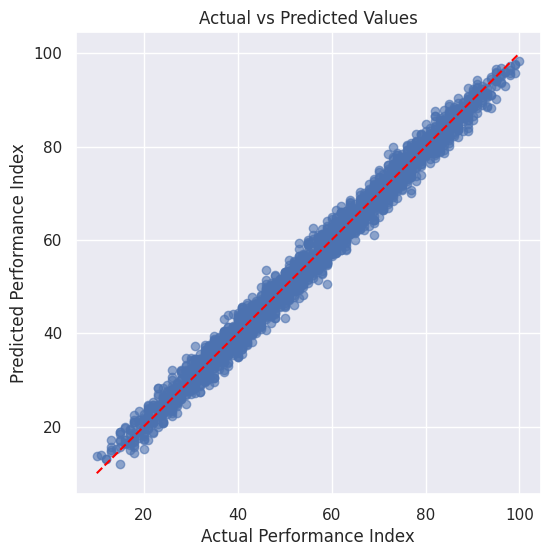

In [ ]:
plt.figure(figsize=(6,6))

# Scatter plot
plt.scatter(y_test, y_pred_lr, alpha=0.6)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')

plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")

plt.title("Actual vs Predicted Values")

plt.show()